# Investigations of file size for hog
* Problem the HOG for cat and dog war way to big
* goal findout why by checking dups and unnormaleitys 

## data colection
colums:
* amount
* dups


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


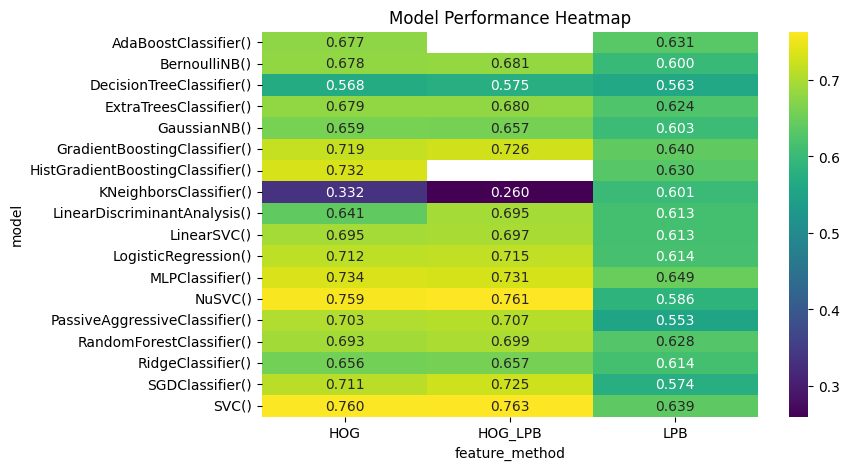

       score            model feature_method time DD:HH:MM:SS  \
45  0.762802            SVC()        HOG_LPB         0:2:0:35   
9   0.759785            SVC()            HOG        0:3:45:31   
22  0.648852  MLPClassifier()            LPB         0:0:0:16   

                                              Warning  
45                                                 []  
9                                                  []  
22  [<warnings.WarningMessage object at 0x000001BC...  


In [38]:
df = pd.read_csv("data/model_data.csv")

# Gör om till pivot-tabell
pivot = df.pivot(index="model", columns="feature_method", values="score")

# Rita heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Model Performance Heatmap")
plt.show()
print(df.sort_values(by="score", ascending=False).groupby("feature_method").head(1))



## Score Heat map 

The score heatmap shows that HOG and HOG_LBP consistently achieve the highest performance across most models, with HOG_LBP slightly outperforming HOG in several cases. However, the improvement is relatively small (approximately 0.3–1%), suggesting that the gain in accuracy is marginal.

Model performance varies depending on the feature extraction method, indicating that there is no universally optimal combination. For example, linear models and SVM-based methods tend to benefit slightly more from HOG_LBP, while the difference is minimal for others.

LBP consistently produces lower scores across all models, typically around 10–20% below HOG-based methods, indicating that it is less effective in terms of raw predictive performance. However, it may still be relevant in scenarios where computational efficiency is a priority.

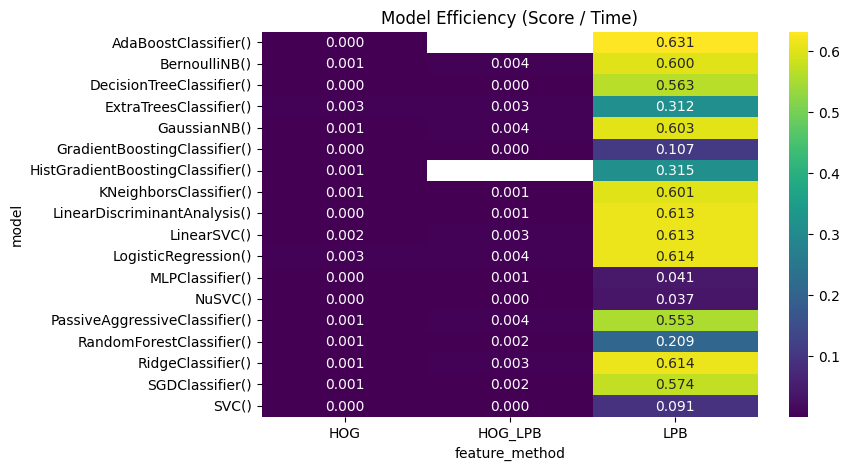

       score                 model feature_method time DD:HH:MM:SS Warning  \
35  0.631423  AdaBoostClassifier()            LPB          0:0:0:1      []   
36  0.714777  LogisticRegression()        HOG_LPB          0:0:3:6      []   
0   0.712381  LogisticRegression()            HOG          0:0:4:5      []   

    time_seconds  efficiency  
35             1    0.631423  
36           186    0.003843  
0            245    0.002908  


In [40]:
def convert_to_seconds(t):
    d, h, m, s = map(int, t.split(":"))
    return d*86400 + h*3600 + m*60 + s

df["time_seconds"] = df["time DD:HH:MM:SS"].apply(convert_to_seconds)
df.loc[df["time_seconds"] == 0, "time_seconds"] = 1
df["efficiency"] = df["score"] / df["time_seconds"]

pivot = df.pivot(index="model", columns="feature_method", values="efficiency")

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("Model Efficiency (Score / Time)")
plt.show()
print(df.sort_values(by="efficiency", ascending=False).groupby("feature_method").head(1))

## Time efficeny heat map 
The efficiency heatmap highlights a clear trade-off between predictive performance and computational cost. While HOG and HOG_LBP achieve higher scores, they exhibit extremely low efficiency values, indicating significantly higher computational time relative to their performance.

In contrast, LBP consistently shows much higher efficiency across all models. This suggests that LBP requires substantially less computational time while still maintaining a reasonable level of performance.

The difference in efficiency is substantial, indicating that HOG-based methods are orders of magnitude more computationally expensive compared to LBP. Therefore, while HOG and HOG_LBP may be preferable when maximizing accuracy, LBP is a strong alternative in time-constrained or resource-limited scenarios

## Choice of models 

I will take the highest score and the most efficent on each feature method and train them:
- HOG for the highest score SVC() with 76.3% and most efficent LogisticRegression() with 0.712381 score/sekund .
- LBP for the highest score MLPClassifier() with 64.89%  and most efficent AdaBoostClassifier() with 0.631423 score/sekund.
- HOG_LBP  for the highest score SVC() with 76.28% and most efficent LogisticRegression() with 0.714777 score/sekund.
